In [2]:
!pip install librosa soundfile tensorflow scikit-learn

In [73]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
DATASET_PATH = "/content/drive/MyDrive/ML projects/Emotion Recognition Model/archive"

In [59]:
print(os.listdir(DATASET_PATH)[:10])

['Actor_03', 'Actor_02', 'Actor_01', 'Actor_04', 'Actor_08', 'Actor_05', 'Actor_06', 'Actor_10', 'Actor_07', 'Actor_09']


In [74]:
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [75]:
def add_noise(data):
    noise = 0.035 * np.random.randn(len(data))
    return data + noise

def pitch_shift(data, sr):
    return librosa.effects.pitch_shift(
        y=data,
        sr=sr,
        n_steps=2
    )

def time_stretch(data):
    return librosa.effects.time_stretch(
        y=data,
        rate=0.8
    )

In [76]:
def extract_features(audio, sr):

    mfcc = np.mean(
        librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        ).T,
        axis=0
    )

    chroma = np.mean(
        librosa.feature.chroma_stft(
            y=audio,
            sr=sr
        ).T,
        axis=0
    )

    mel = np.mean(
        librosa.feature.melspectrogram(
            y=audio,
            sr=sr
        ).T,
        axis=0
    )

    zcr = np.mean(
        librosa.feature.zero_crossing_rate(
            audio
        ).T,
        axis=0
    )

    rms = np.mean(
        librosa.feature.rms(
            y=audio
        ).T,
        axis=0
    )

    centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        ).T,
        axis=0
    )

    rolloff = np.mean(
        librosa.feature.spectral_rolloff(
            y=audio,
            sr=sr
        ).T,
        axis=0
    )

    return np.hstack([
        mfcc,
        chroma,
        mel,
        zcr,
        rms,
        centroid,
        rolloff
    ])

In [77]:
features = []
labels = []

for actor in os.listdir(DATASET_PATH):

    actor_path = os.path.join(
        DATASET_PATH,
        actor
    )

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                emotion_code = file.split("-")[2]
                emotion = emotion_map[emotion_code]

                file_path = os.path.join(
                    actor_path,
                    file
                )

                audio, sr = librosa.load(
                    file_path,
                    duration=3,
                    offset=0.5
                )

                versions = [
                    audio,
                    add_noise(audio),
                    pitch_shift(audio, sr),
                    time_stretch(audio)
                ]

                for sample in versions:

                    features.append(
                        extract_features(
                            sample,
                            sr
                        )
                    )

                    labels.append(
                        emotion
                    )

print("Total Samples =", len(features))

Total Samples = 5760


In [79]:
X = np.array(features)

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

y = to_categorical(y)

print(X.shape)
print(y.shape)

(5760, 184)
(5760, 8)
(5760, 184)
(5760, 8)


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

In [81]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [82]:
model = Sequential()

model.add(
    Dense(
        512,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        256,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    BatchNormalization()
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dense(
        8,
        activation='softmax'
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 512)            │        94,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,304 (1.03 MB)

 Trainable params: 269,512 (1.03 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [83]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [85]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_test,
        y_test
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stop
    ]
)

Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.2684 - loss: 2.0101 - val_accuracy: 0.3620 - val_loss: 1.7064
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3531 - loss: 1.7244 - val_accuracy: 0.4375 - val_loss: 1.5531
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3889 - loss: 1.6199 - val_accuracy: 0.4609 - val_loss: 1.4466
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4180 - loss: 1.5469 - val_accuracy: 0.4349 - val_loss: 1.4441
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4323 - loss: 1.4870 - val_accuracy: 0.5139 - val_loss: 1.3481
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4635 - loss: 1.4266 - val_accuracy: 0.5295 - val_loss: 1.3068
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4716 - loss: 1.3766 - val_accuracy: 0.5304 - val_loss: 1.2830
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4872 - loss: 1.3487 - v

In [86]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

y_true_classes = np.argmax(
    y_test,
    axis=1
)

print(
    "Accuracy:",
    accuracy_score(
        y_true_classes,
        y_pred_classes
    )
)

print(
    "Precision:",
    precision_score(
        y_true_classes,
        y_pred_classes,
        average='weighted'
    )
)

print(
    "Recall:",
    recall_score(
        y_true_classes,
        y_pred_classes,
        average='weighted'
    )
)

print(
    "F1:",
    f1_score(
        y_true_classes,
        y_pred_classes,
        average='weighted'
    )
)

print(
    classification_report(
        y_true_classes,
        y_pred_classes,
        target_names=encoder.classes_
    )
)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.7717013888888888
Precision: 0.7781660259605601
Recall: 0.7717013888888888
F1: 0.7714270545429827
              precision    recall  f1-score   support

       angry       0.84      0.83      0.84       153
        calm       0.66      0.85      0.74       153
     disgust       0.77      0.74      0.75       154
     fearful       0.85      0.81      0.83       154
       happy       0.80      0.69      0.74       154
     neutral       0.81      0.62      0.71        77
         sad       0.76      0.71      0.74       153
   surprised       0.75      0.84      0.79       154

    accuracy                           0.77      1152
   macro avg       0.78      0.76      0.77      1152
weighted avg       0.78      0.77      0.77      1152



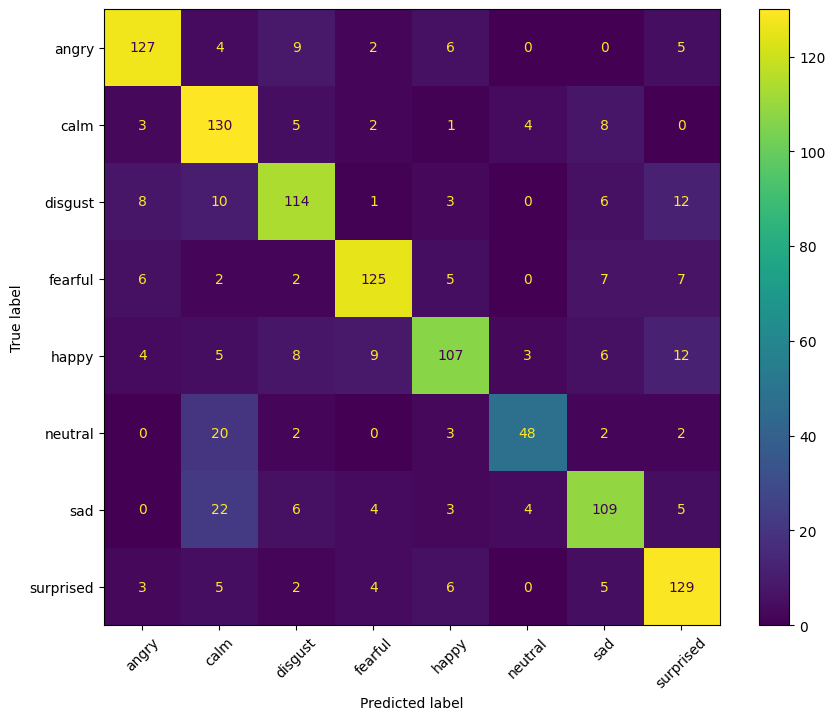

In [87]:
cm = confusion_matrix(
    y_true_classes,
    y_pred_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

fig, ax = plt.subplots(
    figsize=(10,8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()

In [88]:
model.save(
    "emotion_model.keras"
)

In [89]:
import pickle

with open(
    "label_encoder.pkl",
    "wb"
) as f:

    pickle.dump(
        encoder,
        f
    )

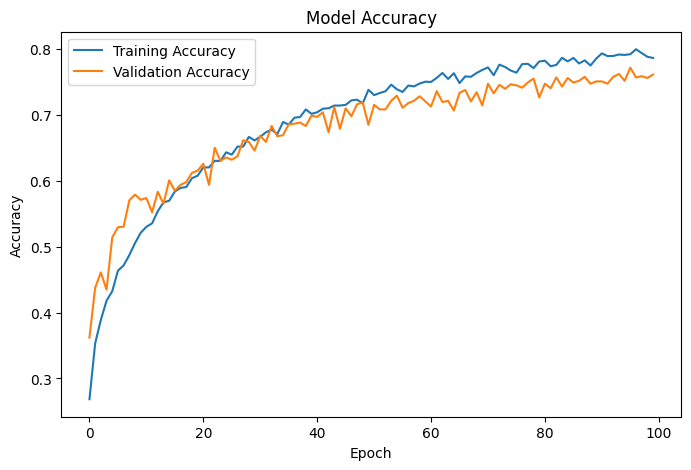

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('accuracy_graph.png')
plt.show()

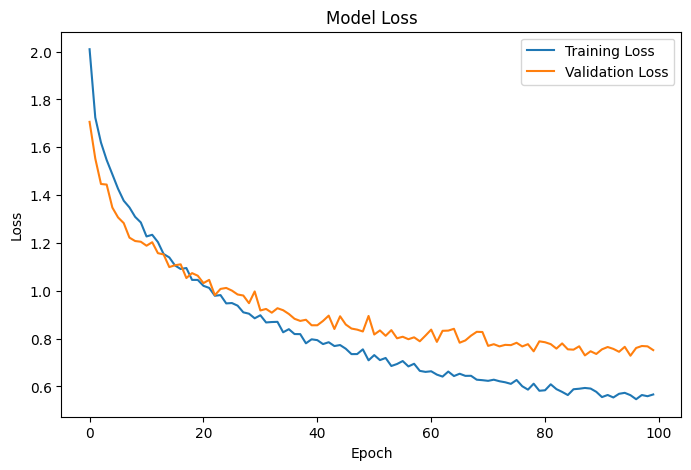

In [91]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig('loss_graph.png')
plt.show()